# Architecture Analysis

In the previous notebook, we analyzed the roofline of the Llama 3.1 model under a given set of conditions. In this chapter, we carry out a comprehensive analysis of the target hardware, covering:

(1) performance modeling of the hardware

(2) performance analysis of the individual compute units, in particular the systolic array

(3) analysis of the bounds and latency of the system as a whole

(4) using the resulting performance model to benchmark the hardware in practice.

In [1]:
import sys
if "code" not in sys.path: sys.path.insert(0, "code")   # model modules live in code/
from tile_model import Hardware, SA1, SA2, VCPU, DMA, SRAM
from helper import plot
from analytical_model import kernel_time

## 1. Accelerator modeling

Begin by laying out the accelerator's components and the links between them, so that the byte movement and latency between them can be seen at a glance.

Note that all units are normalized to **bytes** and cycles.

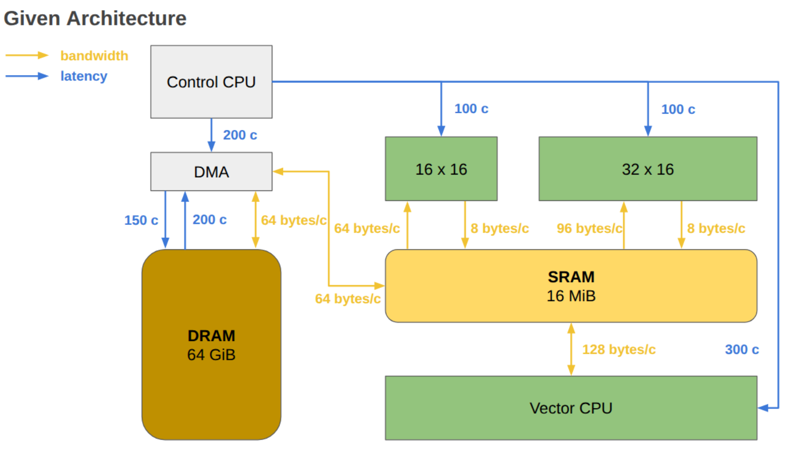

In [2]:
plot("img/architecture.png", 800)

### SA unit Theoratical performance

With the block diagram in place, the performance analysis can be carried out on top of it. We start with the two SA units. The SA is the primary compute unit for matrix operations, and in an LLM it handles essentially all the major GEMMs. Its efficiency depends on both its clock frequency and its design, so the performance analysis of the SA is split into two cases.

The first case is the bandwidth model, in which performance is determined by the bandwidth of the unit, a photonic chip, for example, can complete an entire GEMM operation in a single cycle. By contrast, a conventional GPU tensor core is designed to complete one multiply-accumulate per cycle, so throughput is governed by the reduction size (R in the assignment), with one R consumed per cycle. The performance model built on this assumption is called the MAC model.

### Photonic Chip: Bandwidth model

The figure below gives the formulas for the SA's input, output, and peak performance.

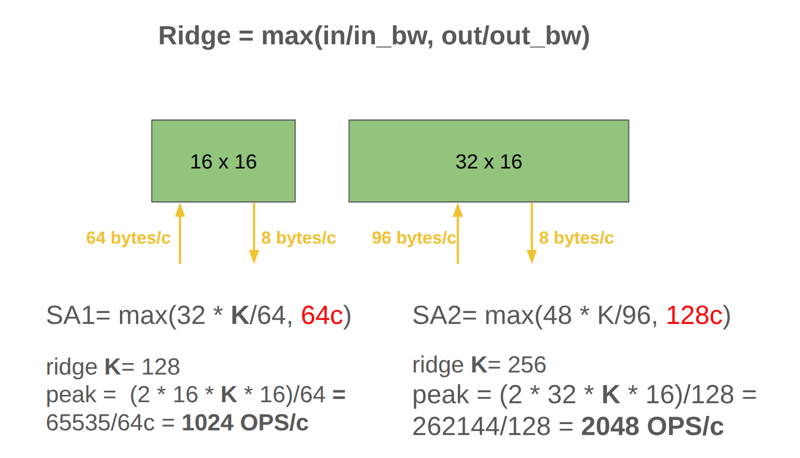

In [3]:
plot("img/SA_ridge.png", 800)

In [4]:
from tile_model import SA1, SA2

for K in [32, 64, 128, 256]:
    print(f"K={K}")
    sa1 = SA1(16, K, compute_model="bandwidth")
    print(f"sa1 macs: {sa1.macs()}, cycle:{sa1.cycle()}")

    sa2 = SA2(32, K, compute_model="bandwidth")
    print(f"sa2 macs: {sa2.macs()}, cycle:{sa2.cycle()}")

K=32
sa1 macs: 8192, cycle:64
sa2 macs: 16384, cycle:128
K=64
sa1 macs: 16384, cycle:64
sa2 macs: 32768, cycle:128
K=128
sa1 macs: 32768, cycle:64
sa2 macs: 65536, cycle:128
K=256
sa1 macs: 65536, cycle:128
sa2 macs: 131072, cycle:128


### Traditional chip (MAC model)

In [5]:
from tile_model import SA1, SA2

for K in [32, 64, 128, 256]:
    print(f"K={K}")
    sa1 = SA1(16, K, compute_model="mac")
    print(f"sa1 macs: {sa1.macs()}, cycle:{sa1.cycle()}")

    sa2 = SA2(32, K, compute_model="mac")
    print(f"sa2 macs: {sa2.macs()}, cycle:{sa2.cycle()}")

K=32
sa1 macs: 8192, cycle:64
sa2 macs: 16384, cycle:128
K=64
sa1 macs: 16384, cycle:64
sa2 macs: 32768, cycle:128
K=128
sa1 macs: 32768, cycle:128
sa2 macs: 65536, cycle:128
K=256
sa1 macs: 65536, cycle:256
sa2 macs: 131072, cycle:256


Under the two models, the work-load balance between SA1 and SA2 is different:

- **Bandwidth model:** SA1 and SA2 finish rows at the same speed (K = 128: 16 rows in 64 cycles vs 32 rows in 128 cycles), so the rows are split **1 : 1**.
- **MAC model:** both arrays take K cycles per job, so SA2 does twice the rows in the same time, and the rows are split **1 : 2**.

The figures below show how the control CPU issues these jobs: one array at a time (sequential), or both arrays together (pipelined).


## 2. Control Latency

Beyond the SA's on-chip performance, control latency also affects its compute efficiency. The following two examples show the latency incurred by pipelined and serialized commands, respectively, during SA computation.

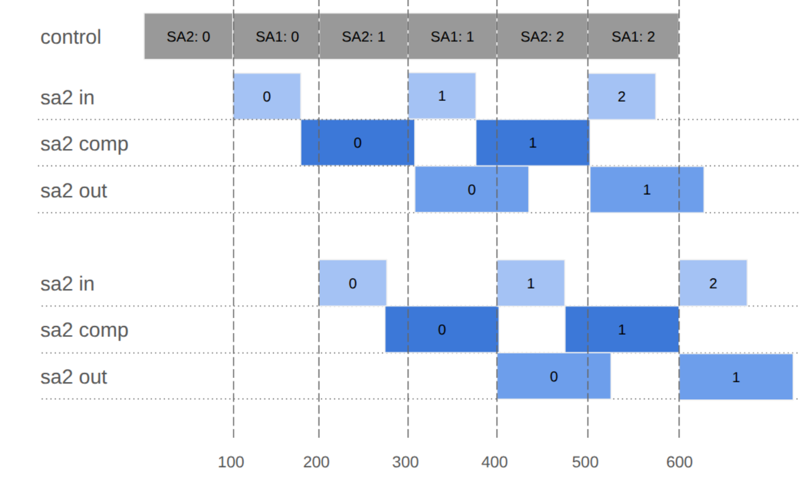

In [6]:
# Serialized control

plot("img/control_seq.png", 800)

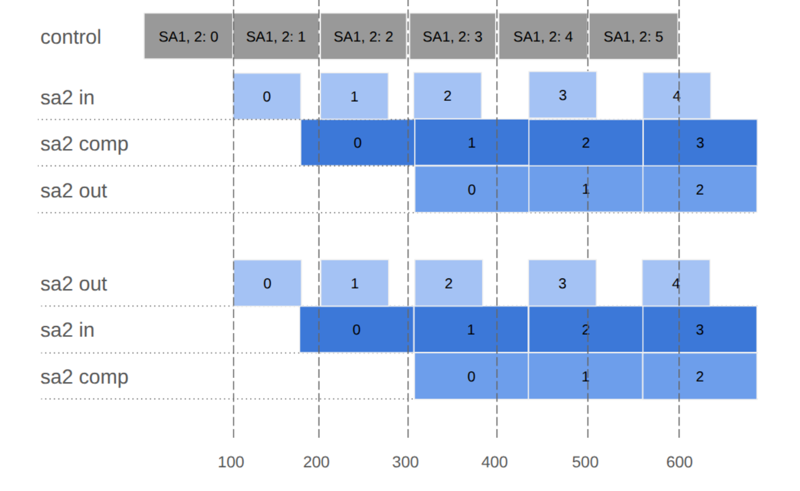

In [7]:
# pipelined control

plot("img/control_pipeline.png", 800)



To model this gap between serialized model and pipelined model, we sample a full workflow: kernel start + DRAM -> SRAM -> SA1 & SA2 -> SRAM -> SRAM -> DRAM

`latency` = every stage serialised (one shot).
`pipelined` = chunked and double-buffered, so the slowest pipe hides the rest.

Example: For Loading 16x256 256x16 int8, running on sa1/sa2, write back to DRAM, a full cycle is written as:

In [8]:
rows, cols, K = 16, 16, 256       # operands 16x256 and 256x16, int8
BW_in, BW_out, latency = 64, 8, 100

load = (rows + cols) * K // BW_in     # in flow
mac = K                               # on chip
drain = rows * cols * 2 // BW_out     # out
stage = max(load, mac)                # the load hides under the MACs

print("serialized  ", latency + stage, "cyc/job")       # CPU blocked by each command
print("pipelined   ", stage, "cyc/job")
print("diff  ", latency, "cyc")# next command issued early

serialized   356 cyc/job
pipelined    256 cyc/job
diff   100 cyc


The entire process can be presented as a **gantt plot**

A gantt plot presents the on-chip cycle of each task and their schedular dependency. We demonstrate the previous control bound analysis with as follows:

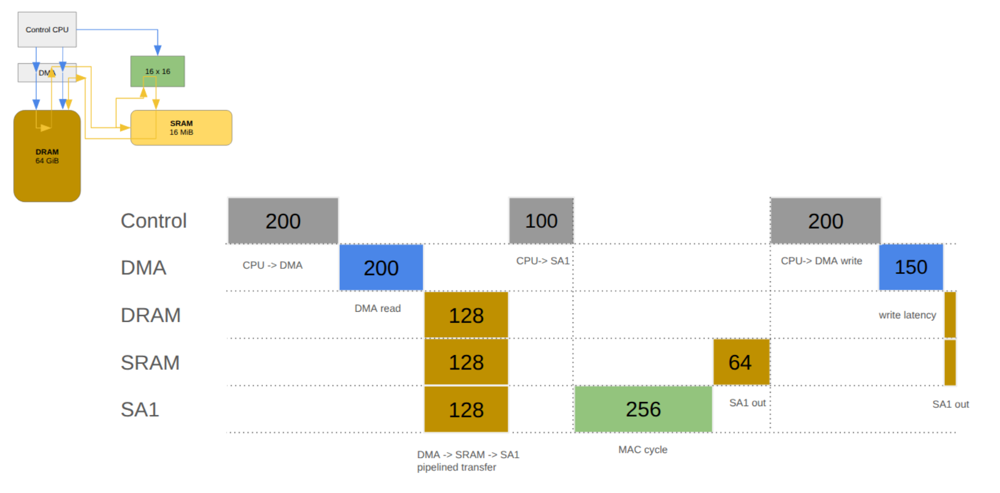

In [9]:
plot("img/schedule_model.png", 1000)

This model can be further written as callable function who simplifies the benchmarking in the next several sections

In [10]:

MB = 2 ** 20
GB = 2 ** 30

## Latency model
BW_DMA = 64                                     # DRAM -> DMA -> SRAM
BW_VCPU = 128                                   # SRAM <-> vector CPU
PORTS = {"sa16": [(16, 64, 8)],                 # (rows, in B/cyc, out B/cyc)
         "sa32": [(32, 96, 8)],
         "both": [(16, 64, 8), (32, 96, 8)]}

byte_list = [16 * MB]
device_list = ["sa16", "sa32", "both"]
K1_list = [32, 64, 128, 256]
K2_list = [32, 64, 128, 256]

print(f"{'size':>8} {'device':>7} {'K1/K2':>9} {'transfer':>12} {'compute':>12} "
      f"{'total':>13} {'transfer%':>10}")
print("-" * 78)

for x in byte_list:
    for unit in device_list:
        # both arrays -> sweep a depth for each; a single array has only K1
        pairs = ([(k1, k2) for k1 in K1_list for k2 in K2_list] if unit == "both"
                 else [(k1, None) for k1 in K1_list])
        for K1, K2 in pairs:
            r = kernel_time(x, unit, K1, K2)
            transfer = r["load"] + r["store"]      # DRAM->SRAM  +  SRAM->DRAM
            compute = r["compute"]
            total = r["latency"]                   # transfer + compute + LAT
            label = f"{K1}/{K2}" if K2 is not None else f"{K1}"
            print(f"{x // MB:>6}MB {unit:>7} {label:>9} {transfer:>12,.0f} {compute:>12,.0f} "
                  f"{total:>13,.0f} {100 * transfer / total:>9.2f}%")
        print("-" * 78)

    size  device     K1/K2     transfer      compute         total  transfer%
------------------------------------------------------------------------------
    16MB    sa16        32      393,216    1,048,576     1,442,642     27.26%
    16MB    sa16        64      327,680      524,288       852,818     38.42%
    16MB    sa16       128      294,912      262,144       557,906     52.86%
    16MB    sa16       256      278,528      262,144       541,522     51.43%
------------------------------------------------------------------------------
    16MB    sa32        32      436,907    1,398,101     1,835,858     23.80%
    16MB    sa32        64      349,525      699,051     1,049,426     33.31%
    16MB    sa32       128      305,835      349,525       656,210     46.61%
    16MB    sa32       256      283,989      174,763       459,602     61.79%
------------------------------------------------------------------------------
    16MB    both     32/32      411,941      599,186     1,01

## 3. Automatic first principle performance model

The process described above can be formalized more precisely as a performance model。

`code/tile_model.py` is a model of the accelerator. Each hardware unit is one small Python class.
The classes do not compute real tensors. They only count time, in **cycles**.
You tell a function the data shape, the data type and the direction, and it returns how many cycles that step takes.

**`Hardware`** keeps all hardware numbers in one place:

- `dma_setup = 200`: cycles to start one DMA transfer
- `dram_read_latency = 200`, `dram_write_latency = 150`: cycles before DRAM starts reading or writing
- `dma_bw = 64`: bytes per cycle between DRAM and SRAM
- `array_latency = 100`: cycles to send one command to SA1 or SA2
- `vector_launch = 300`, `vector_bw = 128`: vector CPU start time, and bytes per cycle
- three switches: `control` (serialized / pipelined), `array_model` (mac / bandwidth), `arithmetic` (native-int8 / safe-int8)

All other classes read their numbers from `hw`. To try a different hardware, change one value in `Hardware(...)`. No formula has to change.

**`DMA`** copies data between DRAM and SRAM:

    time = dma_setup + DRAM latency + bytes / dma_bw

**`SA1` and `SA2`** are the two systolic arrays that do the matrix multiplications.
SA1 has 16 rows and SA2 has 32 rows. Both have 16 output columns.
Data goes in at 64 bytes/cycle (SA1) or 96 bytes/cycle (SA2), and results come out at 8 bytes/cycle on both.

    time = array_latency + max(input time, MAC time) + output time

Input and MACs overlap, so only the longer one counts.
Each part has its own function: `input_cycles()`, `compute_cycles()` and `output_cycles()`. Comparing the three shows which part is the bottleneck.

**`VCPU`** is the vector CPU. Its time depends only on how many bytes it reads and writes:

    time = vector_launch + (bytes read + bytes written) / vector_bw

**`SRAM`** takes no time. It only keeps track of memory:
`allocate(name, shape, dtype)` reserves a buffer and `free(name)` releases it.
It raises `MemoryError` when more than 16 MiB is in use, and records the highest use in `peak_bytes`.


### The performance model for simulating the previous process:

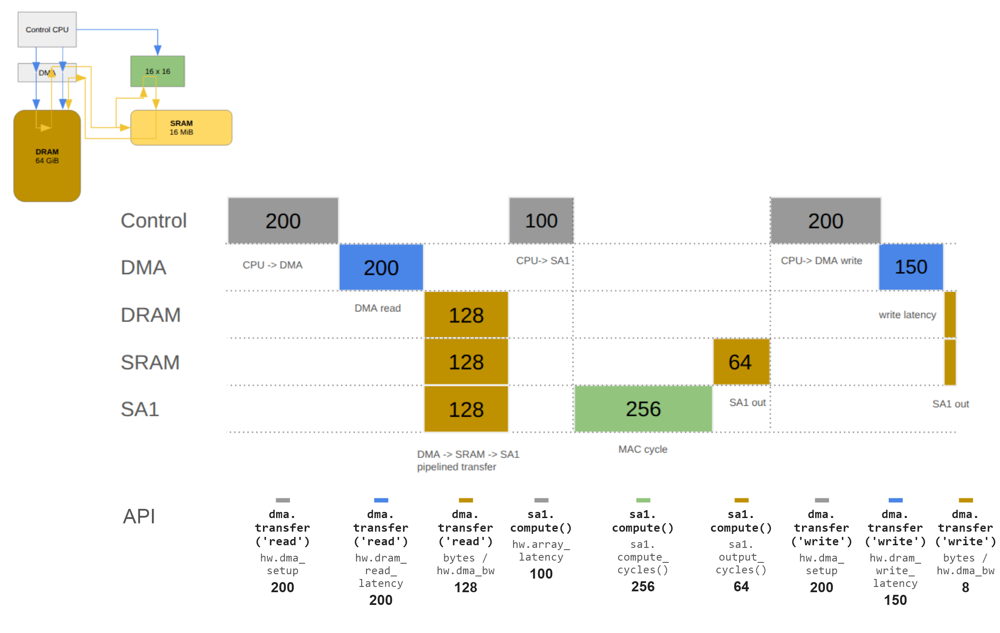

In [14]:
plot("img/schedule_model_api.png", 1000)

### The API correspondance:

In [12]:
from tile_model import Hardware, SA1, DMA, SRAM

hw = Hardware()
sram, dma, sa1, sa2 = SRAM(hw=hw), DMA(hw=hw), SA1(), SA2()

# [1] both operands (16x256 and 256x16 int8 = 8192 B) in one stream
load = dma.transfer((32, 256), 8, 'read', sram, 'AB8')
# [2] command latency + MACs + output drain
job = sa1.compute(16, 256, 8, hw=hw, sram=sram, output='S16')
# [3] the 16x16 int16 result (512 B) back to DRAM
store = dma.transfer((16, 16), 16, 'write', sram, 'S16', release=True)

print( "*" * 12, "SA1", "*" * 12)
print("load ", load, "cycles")
print("job  ", job, "cycles")
print("store", store, "cycles")
print("total", load + job + store, "cycles")


#################### SA2
load = dma.transfer((64, 256), 8, 'read', sram, 'sa28')
job = sa2.compute(32, 256, 8, hw=hw, sram=sram, output='S16')
store = dma.transfer((32, 16), 16, 'write', sram, 'S16', release=True)

print( "*" * 12, "SA2", "*" * 12)
print("load ", load, "cycles")
print("job  ", job, "cycles")
print("store", store, "cycles")
print("total", load + job + store, "cycles")

************ SA1 ************
load  528 cycles
job   420 cycles
store 358 cycles
total 1306 cycles
************ SA2 ************
load  656 cycles
job   484 cycles
store 366 cycles
total 1506 cycles


### Using performance model recheck SA1 SA2 performance

In [13]:
hw = Hardware()
sa1, sa2 = SA1(), SA2()
dma, vcpu, sram = DMA(hw=hw), VCPU(hw=hw), SRAM(hw=hw)

sa1.compute(16, 128, 8)

dma.transfer((16, 128), 16, 'read', sram, 'Q16')

vcpu.transform(sram, 'Q16', 'Q8', 8,
                        read_passes=2, free_input=True)


for sa, name in ((SA1(), 'SA1'), (SA2(), 'SA2')):
  for K in (128, 256):
      job = type(sa)(K=K)
      print(f'{name} K={K}: input {job.input_cycles()} cyc, compute {job.compute_cycles()} cyc, drain {job.output_cycles()} cyc, '
            f'+100 command -> period {100+max(job.input_cycles(), job.compute_cycles())} cyc, {job.macs()} MACs')

SA1 K=128: input 64 cyc, compute 128 cyc, drain 64 cyc, +100 command -> period 228 cyc, 32768 MACs
SA1 K=256: input 128 cyc, compute 256 cyc, drain 64 cyc, +100 command -> period 356 cyc, 65536 MACs
SA2 K=128: input 64 cyc, compute 128 cyc, drain 128 cyc, +100 command -> period 228 cyc, 65536 MACs
SA2 K=256: input 128 cyc, compute 256 cyc, drain 128 cyc, +100 command -> period 356 cyc, 131072 MACs


### Performance analysis


    16MB    both   256/256      281,805      104,858       387,512     72.72%

**1. The transfer proportion is a bottleneck readout.** 72.72% (both, K=256)
  means the kernel is transfer-dominated and widening DRAM would help.
  23.80% (sa32, K=32) means it's compute-dominated and DRAM is irrelevant.
  The proportion moves from 24% to 73% purely from choosing K and the device

    16777216B      sa16  256    278,528.0    262,144.0    541,522.0     51.43%


The size column barely matters once past the fixed latency: 16 and 32MiB give nearly identical percentages (58.88 / 58.93),
  because both transfer and compute scale linearly. K and device are the
  real variables in this sweep; x mostly is not.

    16MB    sa16       128      294,912      262,144       557,906     52.86%
    16MB    sa16       256      278,528      262,144       541,522     51.43%

**2. The 8 B/c output port is the bottleneck.** Inputs come in at
  64–96 B/c and DMA at 64, but results leave at 8. the "compute" column is pure port time.

**3. K >= 128 Memory bound, <= computation bound**



### Conclusion

**Bandwidth model — the output drain is the floor.** With compute free, a job costs `max(input, drain)`. The drain is fixed at 512 B (SA1) / 1024 B (SA2) over a common 8 B/c port -> 64 / 128 cycles *independent of K*, while the input takes K/2 cycles on both arrays. So SA1 is drain-bound below K=128 and input-bound above it; SA2 stays drain-bound all the way to K=256, where the two ports tie. Shallow reductions pay for a drain they cannot fill.

**MAC model — the reduction depth is the floor.** `BW_in` is provisioned so that the input costs `(rows+16)·K / BW_in` = K/2 cycles on *both* arrays (32K/64 and 48K/96), exactly half the K cycles of MAC streaming, so the input port never binds. A job costs 100 (command) + K, and the drain hides behind the next job: 228 cycles at K=128, 356 at K=256, on either array. The ceiling is 552 MAC/cycle at K=256 (SA1 184 + SA2 368) and 431 at K=128 — set by the command latency and by K, not by a port.

**SA2's extra silicon buys nothing until K≥128**

Quantization overflow: int8 -> int16 encountered overflow, especially in sa. int 8 2**7 * K (2**) <= int16 2**15. If K=256,